In [224]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [225]:
# Hyperparameters
input_size = 784  # 28x28 pixels for MNIST
hidden_size = 500
num_classes = 10
num_epochs = 10
batch_size = 100
learning_rate = 0.001

In [226]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

=== MNIST Dataset Information ===
Number of training samples: 60000
Number of test samples: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10
Class names: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

Displaying sample images...


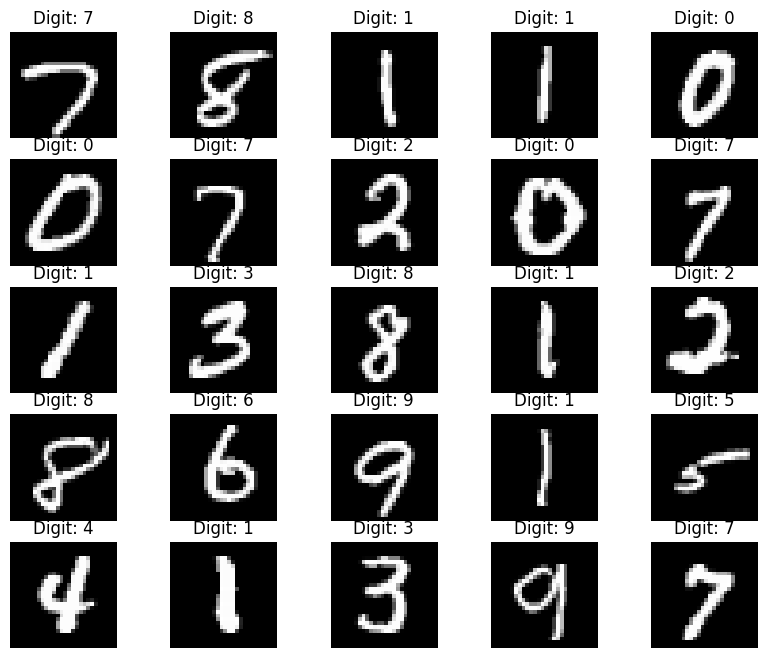


Analyzing class distribution...


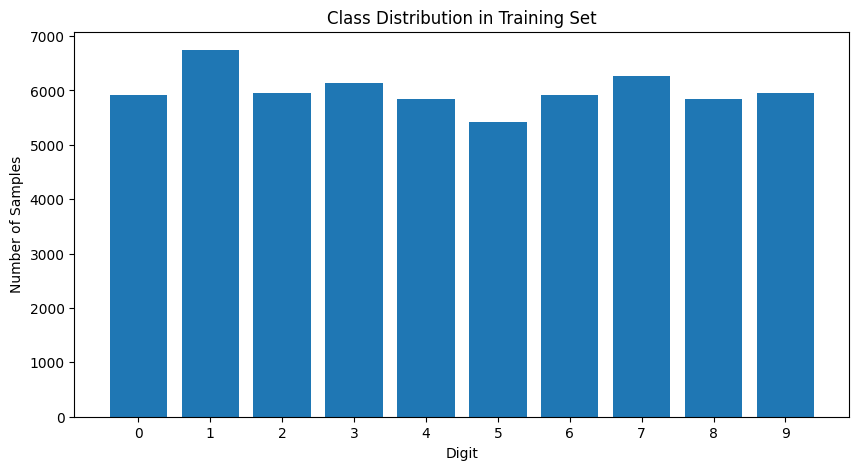


Class distribution counts:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Calculating pixel statistics...

=== Pixel Value Statistics ===
Mean pixel value: 0.1220
Standard deviation: 0.2983
Min pixel value: 0.0000
Max pixel value: 1.0000


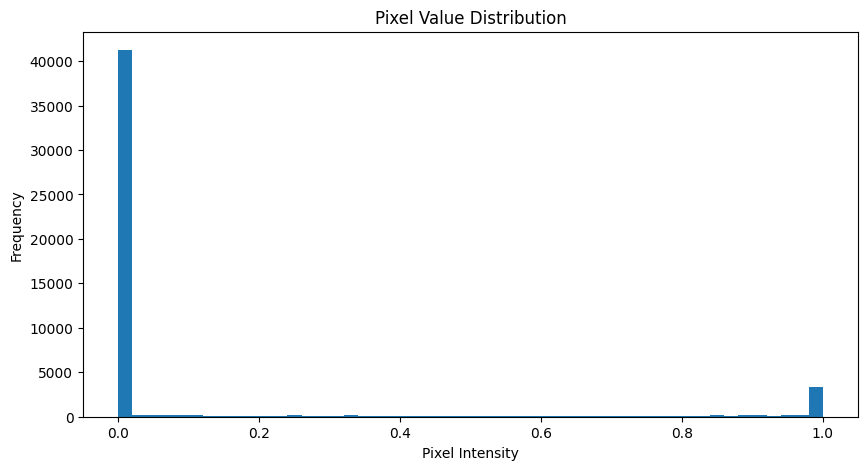


Showing example with pixel values...


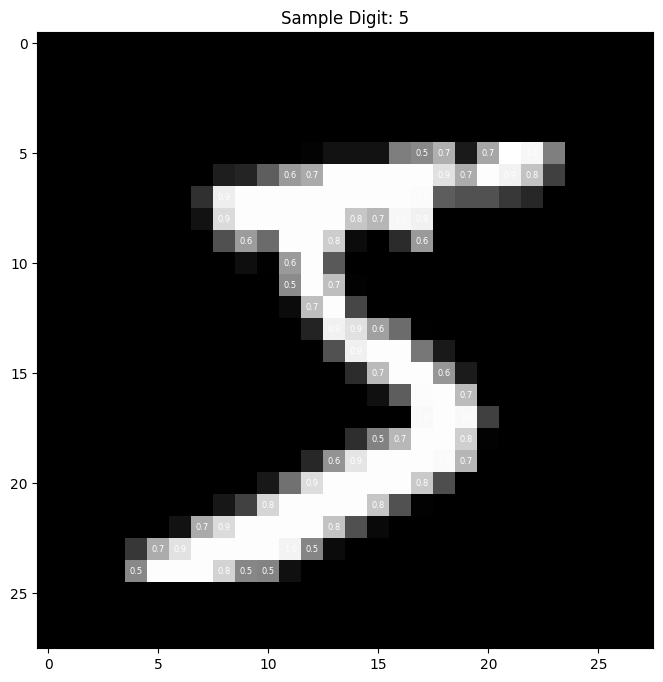

In [227]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

# Download and load training dataset
train_dataset = torchvision.datasets.MNIST(root='./data',
                                         train=True,
                                         transform=transform,
                                         download=True)

# Download and load test dataset
test_dataset = torchvision.datasets.MNIST(root='./data',
                                        train=False,
                                        transform=transform)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset,
                         batch_size=64,
                         shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                        batch_size=64,
                        shuffle=False)

# 1. Basic Dataset Information
def print_dataset_info():
    print("=== MNIST Dataset Information ===")
    print(f"Number of training samples: {len(train_dataset)}")
    print(f"Number of test samples: {len(test_dataset)}")
    print(f"Image shape: {train_dataset[0][0].shape}")  # Shape of first image
    print(f"Number of classes: {len(train_dataset.classes)}")
    print(f"Class names: {train_dataset.classes}")

# 2. Visualize Sample Images
def visualize_samples():
    # Get some sample images
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5

    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
        img, label = train_dataset[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(f"Digit: {label}")
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

# 3. Class Distribution
def plot_class_distribution():
    # Count samples per class
    train_labels = [label for _, label in train_dataset]
    unique, counts = np.unique(train_labels, return_counts=True)

    plt.figure(figsize=(10, 5))
    plt.bar(unique, counts)
    plt.title("Class Distribution in Training Set")
    plt.xlabel("Digit")
    plt.ylabel("Number of Samples")
    plt.xticks(unique)
    plt.show()

    print("\nClass distribution counts:")
    for digit, count in zip(unique, counts):
        print(f"Digit {digit}: {count} samples")

# 4. Display Pixel Value Statistics
def pixel_statistics():
    # Get a batch of images
    images, _ = next(iter(train_loader))
    images = images.numpy()

    print("\n=== Pixel Value Statistics ===")
    print(f"Mean pixel value: {images.mean():.4f}")
    print(f"Standard deviation: {images.std():.4f}")
    print(f"Min pixel value: {images.min():.4f}")
    print(f"Max pixel value: {images.max():.4f}")

    # Plot histogram of pixel values
    plt.figure(figsize=(10, 5))
    plt.hist(images.ravel(), bins=50, range=(0, 1))
    plt.title("Pixel Value Distribution")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

# 5. Show Example with Pixel Values
def show_image_with_pixels():
    img, label = train_dataset[0]
    img = img.squeeze().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.title(f"Sample Digit: {label}")

    # Add pixel values
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            val = img[i, j]
            if val > 0.5:  # Only show values for darker pixels
                plt.text(j, i, f'{val:.1f}',
                        ha='center', va='center', color='white', fontsize=6)
    plt.show()

# Run all analyses
if __name__ == '__main__':
    # Basic information
    print_dataset_info()

    # Visualize samples
    print("\nDisplaying sample images...")
    visualize_samples()

    # Class distribution
    print("\nAnalyzing class distribution...")
    plot_class_distribution()

    # Pixel statistics
    print("\nCalculating pixel statistics...")
    pixel_statistics()

    # Show image with pixel values
    print("\nShowing example with pixel values...")
    show_image_with_pixels()

In [228]:
# Load and preprocess MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='./data',
                                         train=True,
                                         transform=transforms.ToTensor(),
                                         download=True)

test_dataset = torchvision.datasets.MNIST(root='./data',
                                        train=False,
                                        transform=transforms.ToTensor())

# Data loaders
train_loader = DataLoader(dataset=train_dataset,
                         batch_size=batch_size,
                         shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                        batch_size=batch_size,
                        shuffle=False)


In [229]:
# ANN Model
class ANN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ANN, self).__init__()
        self.flatten = nn.Flatten() #nn.Flatten() is a PyTorch layer that reshapes input tensors by flattening them into a 1D vector.For MNIST, images are 28×28 pixels (and typically single-channel, i.e., grayscale), so their shape is [batch_size, 1, 28, 28]. nn.Flatten() converts each image to a 1D vector of 784 elements ([batch_size, 784])
        self.layer1 = nn.Linear(input_size, hidden_size) #a linear transformation: output = input @ weight.T + bias, where weight is a matrix of shape [hidden_size, input_size] and bias is a vector of length hidden_size
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, num_classes)

    #Build a Neural Network
    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

In [230]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Initialize the model
model = ANN(input_size, hidden_size, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

# Train the model
def train_model():
    model.train()
    best_val_loss = float('inf')
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i+1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}], Loss: {loss.item():.4f}')
        print("\nTesting started...")
        best_val_loss = test_model(best_val_loss)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [231]:
# Test the model
def test_model(best_val_loss):
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        total_loss = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss = criterion(outputs, labels)
            total_loss += loss.item()





        accuracy = 100 * correct / total
        print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
        avg_loss = total_loss / len(test_loader)
        print(f"len of test loader = {len(test_loader)}")
        print(f'Average Loss: {avg_loss:.4f}')
        if avg_loss < best_val_loss:
          best_val_loss = avg_loss
          torch.save(model.state_dict(), save_path)
          print(f"💾 Best model saved with val loss {best_val_loss:.4f} to {save_path}")
        scheduler.step(avg_loss)

        # Show current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f"📉 Current Learning Rate: {current_lr:.6f}")

        return best_val_loss

In [232]:
save_path = 'ann_model.pth'

In [233]:
# Run training and testing
if __name__ == '__main__':
    print("Training started...")
    train_model()



Training started...
Epoch [1/10], Step [100], Loss: 0.4333
Epoch [1/10], Step [200], Loss: 0.4059
Epoch [1/10], Step [300], Loss: 0.1696
Epoch [1/10], Step [400], Loss: 0.2692
Epoch [1/10], Step [500], Loss: 0.2798
Epoch [1/10], Step [600], Loss: 0.2296

Testing started...
Accuracy of the model on the test images: 95.86%
len of test loader = 100
Average Loss: 0.1439
💾 Best model saved with val loss 0.1439 to ann_model.pth
📉 Current Learning Rate: 0.001000
Epoch [2/10], Step [100], Loss: 0.1998
Epoch [2/10], Step [200], Loss: 0.1363
Epoch [2/10], Step [300], Loss: 0.0951
Epoch [2/10], Step [400], Loss: 0.0828
Epoch [2/10], Step [500], Loss: 0.1112
Epoch [2/10], Step [600], Loss: 0.0775

Testing started...
Accuracy of the model on the test images: 97.00%
len of test loader = 100
Average Loss: 0.1000
💾 Best model saved with val loss 0.1000 to ann_model.pth
📉 Current Learning Rate: 0.001000
Epoch [3/10], Step [100], Loss: 0.0808
Epoch [3/10], Step [200], Loss: 0.0707
Epoch [3/10], Step [30

In [234]:
# prompt: load the save path and test it

# Test loading the model
loaded_model = ANN(input_size, hidden_size, num_classes).to(device)
loaded_model.load_state_dict(torch.load(save_path))
loaded_model.eval()

# Test the loaded model
def test_loaded_model():
    loaded_model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = loaded_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f'Accuracy of the loaded model on the test images: {accuracy:.2f}%')

print("\nTesting loaded model...")
test_loaded_model()



Testing loaded model...
Accuracy of the loaded model on the test images: 98.07%
